In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib

In [2]:
# Dataset path
DATASET_PATH = pathlib.Path(
    r"D:\PROJECTS\ML_projects\FOD_Project\dataset_greyscale_new"
)

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Number of classes
NUM_CLASSES = 4

# Random seed
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 1418 files belonging to 4 classes.
Found 300 files belonging to 4 classes.
Found 311 files belonging to 4 classes.


In [4]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

Classes:
['fuelcap', 'pliers', 'rock', 'screwdrivers']


In [5]:
for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

Image batch shape : (32, 128, 128, 1)
Label batch shape : (32,)


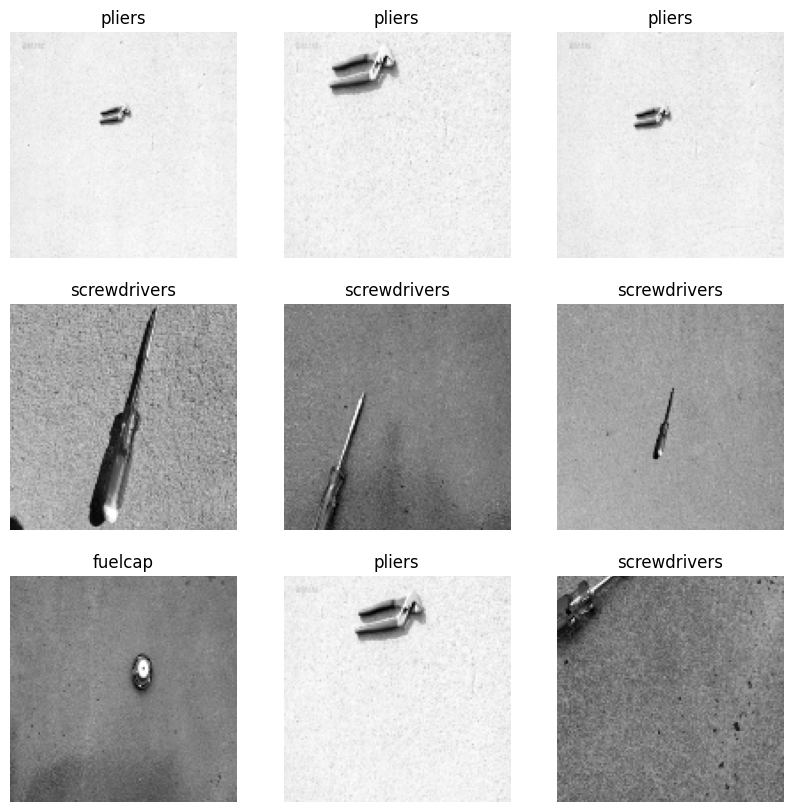

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
#optimize pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [8]:
# data augmentaion
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomZoom(0.10)
])

In [9]:
#CNN model
model = keras.Sequential([

    layers.Input(shape=(128, 128, 1)),

    # Data augmentation
    #data_augmentation,

    # Normalize pixel values (0-255 → 0-1)
    layers.Rescaling(1./255),

    # --------------------------
    # Feature Extraction
    # --------------------------

    layers.Conv2D(
        filters=16,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    # --------------------------
    # Classification
    # --------------------------

    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')

    ])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,541 (99.77 KB)

 Trainable params: 25,541 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    #callbacks=[early_stop]
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.3660 - loss: 1.3716 - val_accuracy: 0.4333 - val_loss: 1.1843
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.4908 - loss: 1.1595 - val_accuracy: 0.7100 - val_loss: 0.8891
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.6968 - loss: 0.7970 - val_accuracy: 0.7100 - val_loss: 0.6189
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7137 - loss: 0.6492 - val_accuracy: 0.7233 - val_loss: 0.5576
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.7525 - loss: 0.5763 - val_accuracy: 0.7767 - val_loss: 0.5099
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.7772 - loss: 0.5477 - val_accuracy: 0.7767 - val_loss: 0.4578
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7757 - loss: 0.5343 - val_accuracy: 0.7767 - val_loss: 0.4873
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7821 - loss: 0.4911 - val_accuracy: 0.7767

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
              precision    recall  f1-score   support

     fuelcap       0.43      0.92      0.59        38
      pliers       1.00      1.00      1.00       126
        rock       1.00      1.00      1.00        50
screwdrivers       0.94      0.53      0.68        97

    accuracy                           0.84       311
   macro avg       0.84      0.86      0.82       311
weighted avg       0.91      0.84      0.85       311

[[ 35   0   0   3]
 [  0 126   0   0]
 [  0   0  50   0]
 [ 46   0   0  51]]


In [14]:
model.save(r"D:\PROJECTS\ML_projects\FOD_Project\models\fod_classifier.keras")

In [16]:
import pickle

with open(r"D:\PROJECTS\ML_projects\FOD_Project\models\training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [18]:
import json



with open(r"D:\PROJECTS\ML_projects\FOD_Project\models\class_names.json", "w") as f:
    json.dump(class_names, f)

In [19]:
model.save_weights(r"D:\PROJECTS\ML_projects\FOD_Project\weights\fod_classifier.weights.h5")